# A/B Experiment — Statistical Analysis: Predictive KEDA vs Vanilla HPA
**Three independent runs** (mw2_2, mw2_3, mw2_4) · MAX_WORKERS=2 · 120 users

Round naming: `round_a_<id>` = Vanilla HPA · `round_b_<id>` = Predictive KEDA

Sections: 1 RPS+CPU · 2 Scale-Up Lag · 3 CPU Utilisation · 4 Latency (P50/P95/P99) · 5 RPS · 6 Over-Provisioning · 7 Summary · 8 Statistical Tests

In [5]:
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import wilcoxon

RESULTS      = Path('../test_deployment/locusts/results')
TIMESTAMPS_F = Path('../test_deployment/locusts/experiment_timestamps.json')
PROM         = 'http://localhost:9091/api/v1/query_range'

RUNS = [
    {'hpa': 'round_a_mw2_2', 'keda': 'round_b_mw2_2', 'label': 'Run 1 (mw2_2)'},
    {'hpa': 'round_a_mw2_3', 'keda': 'round_b_mw2_3', 'label': 'Run 2 (mw2_3)'},
    {'hpa': 'round_a_mw2_4', 'keda': 'round_b_mw2_4', 'label': 'Run 3 (mw2_4)'},
]
N_RUNS     = len(RUNS)
RUN_ALPHAS = [0.35, 0.65, 0.95]  # for overlaid timeseries

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLOR_HPA  = 'tomato'
COLOR_KEDA = 'steelblue'
COLOR_PRED = 'darkorange'
LABEL_HPA  = 'Vanilla HPA'
LABEL_KEDA = 'Predictive KEDA'
IDLE_PAD_S = 30

SCENARIO_NAMES = [
    '1. Linear Ramp',
    '2. Step Function',
    '3. Sine Wave',
    '4. Multi Spike',
    '5. Random Walk',
    '6. Quiet + Burst',
]
SHORT_NAMES = ['Linear\nRamp', 'Step\nFunc.', 'Sine\nWave',
               'Multi\nSpike', 'Random\nWalk', 'Quiet+\nBurst']

with open(TIMESTAMPS_F) as f:
    timestamps = json.load(f)

print('Setup complete.')
print('Runs:', [r['label'] for r in RUNS])
print('Scenarios:', SCENARIO_NAMES)

Setup complete.
Runs: ['Run 1 (mw2_2)', 'Run 2 (mw2_3)', 'Run 3 (mw2_4)']
Scenarios: ['1. Linear Ramp', '2. Step Function', '3. Sine Wave', '4. Multi Spike', '5. Random Walk', '6. Quiet + Burst']


In [6]:
def load_history(round_id: str) -> pd.DataFrame:
    path = RESULTS / f'round_{round_id}_stats_history.csv'
    df = pd.read_csv(path)
    df = df[df['Name'] == 'Aggregated'].copy()
    for col in ['50%', '95%', '99%', '100%']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.sort_values('Timestamp').reset_index(drop=True)

def load_stats(round_id: str) -> pd.DataFrame:
    return pd.read_csv(RESULTS / f'round_{round_id}_stats.csv')

def slice_scenario(df, name, round_key, min_rps=0.5, pad_s=IDLE_PAD_S):
    ts = timestamps[round_key][name]
    start, end = ts['start_unix'], ts['end_unix']
    full = df[(df['Timestamp'] >= start - pad_s) & (df['Timestamp'] <= end + pad_s)].copy()
    full['t'] = full['Timestamp'] - start
    active = df[(df['Timestamp'] >= start) & (df['Timestamp'] <= end)].copy()
    active['t'] = active['Timestamp'] - start
    active = active[active['Requests/s'] > min_rps].copy()
    return full, active

def clip_to_scenarios(df, round_key):
    mask = pd.Series(False, index=df.index)
    for name in SCENARIO_NAMES:
        ts = timestamps[round_key][name]
        mask |= (df['Timestamp'] >= ts['start_unix']) & (df['Timestamp'] <= ts['end_unix'])
    return df[mask].reset_index(drop=True)

CPU_UTIL_Q = (
    'sum(rate(container_cpu_usage_seconds_total'
    '{pod=~"cpu-service-.*",container!="POD"}[30s]))'
    '/sum(kube_pod_container_resource_limits'
    '{pod=~"cpu-service-.*",resource="cpu",container!="POD"})'
)

def prom_range(query, start, end, step='15s'):
    r = requests.get(PROM,
                     params={'query': query, 'start': start, 'end': end, 'step': step},
                     timeout=10)
    result = r.json()['data']['result']
    if not result:
        return pd.DataFrame(columns=['ts', 'value'])
    df = pd.DataFrame(result[0]['values'], columns=['ts', 'value'])
    df['ts']    = df['ts'].astype(float)
    df['value'] = pd.to_numeric(df['value'])
    return df

def add_sec(df, start):
    if df.empty:
        return df
    df = df.copy()
    df['sec'] = df['ts'] - start
    return df

def fetch_scenario(round_key, scenario, pad_s=IDLE_PAD_S):
    ts_info = timestamps[round_key][scenario]
    start, end = ts_info['start_unix'], ts_info['end_unix']
    replicas = add_sec(
        prom_range('kube_deployment_status_replicas_ready{deployment="cpu-service"}',
                   start - pad_s, end + pad_s), start)
    cpu  = add_sec(prom_range(CPU_UTIL_Q, start - pad_s, end + pad_s), start)
    pred = add_sec(prom_range('gru_predicted_cpu_util', start - pad_s, end + pad_s), start)
    return {'replicas': replicas, 'cpu': cpu, 'pred': pred,
            'start': start, 'end': end, 'pad': pad_s}

def _step_interp(rep_df, sec_arr):
    out = []
    for s in sec_arr:
        prev = rep_df[rep_df['sec'] <= s]
        out.append(float(prev['value'].iloc[-1]) if not prev.empty
                   else float(rep_df['value'].iloc[0]))
    return np.array(out)

def _med(df, col):
    return int(df[col].median()) if not df.empty and df[col].notna().any() else 0

def agg_runs(values_per_run):
    """values_per_run: list of N_RUNS sequences of length N_SCENARIOS.
    None entries become NaN and are excluded from mean/std.
    Returns (means, stds) both shape (N_SCENARIOS,)."""
    arr = np.array([[v if v is not None else np.nan for v in vals]
                    for vals in values_per_run], dtype=float)
    ddof = 1 if N_RUNS > 1 else 0
    with np.errstate(all='ignore'):
        means = np.nanmean(arr, axis=0)
        stds  = np.nanstd(arr, axis=0, ddof=ddof)
    return means, stds

def summary_from_history(hist: pd.DataFrame) -> dict:
    active = hist[hist['Requests/s'] > 0.5].copy()
    return {
        'Median (ms)': int(active['50%'].median()),
        'P95 (ms)':    int(active['95%'].median()),
        'P99 (ms)':    int(active['99%'].median()),
        'Max (ms)':    int(active['100%'].max()),
        'Avg RPS':     float(active['Requests/s'].mean()),
    }

def get_total_from_stats(stats_df, col):
    agg = stats_df[stats_df['Name'] == 'Aggregated']
    return int(agg[col].iloc[0]) if not agg.empty and col in agg.columns else 0

print('Helpers defined.')

Helpers defined.


In [7]:
hist_raw     = {}
hist_clipped = {}
stats_dfs    = {}

for run in RUNS:
    for key in (run['hpa'], run['keda']):
        rid = key.replace('round_', '')
        hist_raw[key]     = load_history(rid)
        hist_clipped[key] = clip_to_scenarios(hist_raw[key], key)
        stats_dfs[key]    = load_stats(rid)
        print(f'{key}: {len(hist_clipped[key])} clipped / {len(hist_raw[key])} raw rows')

try:
    ts0  = timestamps[RUNS[-1]['hpa']][SCENARIO_NAMES[0]]
    test = prom_range('kube_deployment_status_replicas_ready{deployment="cpu-service"}',
                      ts0['start_unix'], ts0['end_unix'])
    print(f'Prometheus OK — {len(test)} points for {SCENARIO_NAMES[0]} (last run)')
except Exception as e:
    print(f'Prometheus unavailable: {e}')

round_a_mw2_2: 3708 clipped / 5206 raw rows
round_b_mw2_2: 3713 clipped / 5211 raw rows
round_a_mw2_3: 3712 clipped / 5211 raw rows
round_b_mw2_3: 3714 clipped / 5211 raw rows
round_a_mw2_4: 3714 clipped / 5211 raw rows
round_b_mw2_4: 3714 clipped / 5211 raw rows
Prometheus OK — 41 points for 1. Linear Ramp (last run)


---
## 1 — RPS and CPU During Each Scenario

All three runs overlaid. Opacity increases Run 1 → Run 3.  
Solid = Requests/s (left axis). Dashed = CPU utilisation [0, 1] (right axis).  
Red = Vanilla HPA, Blue = Predictive KEDA.

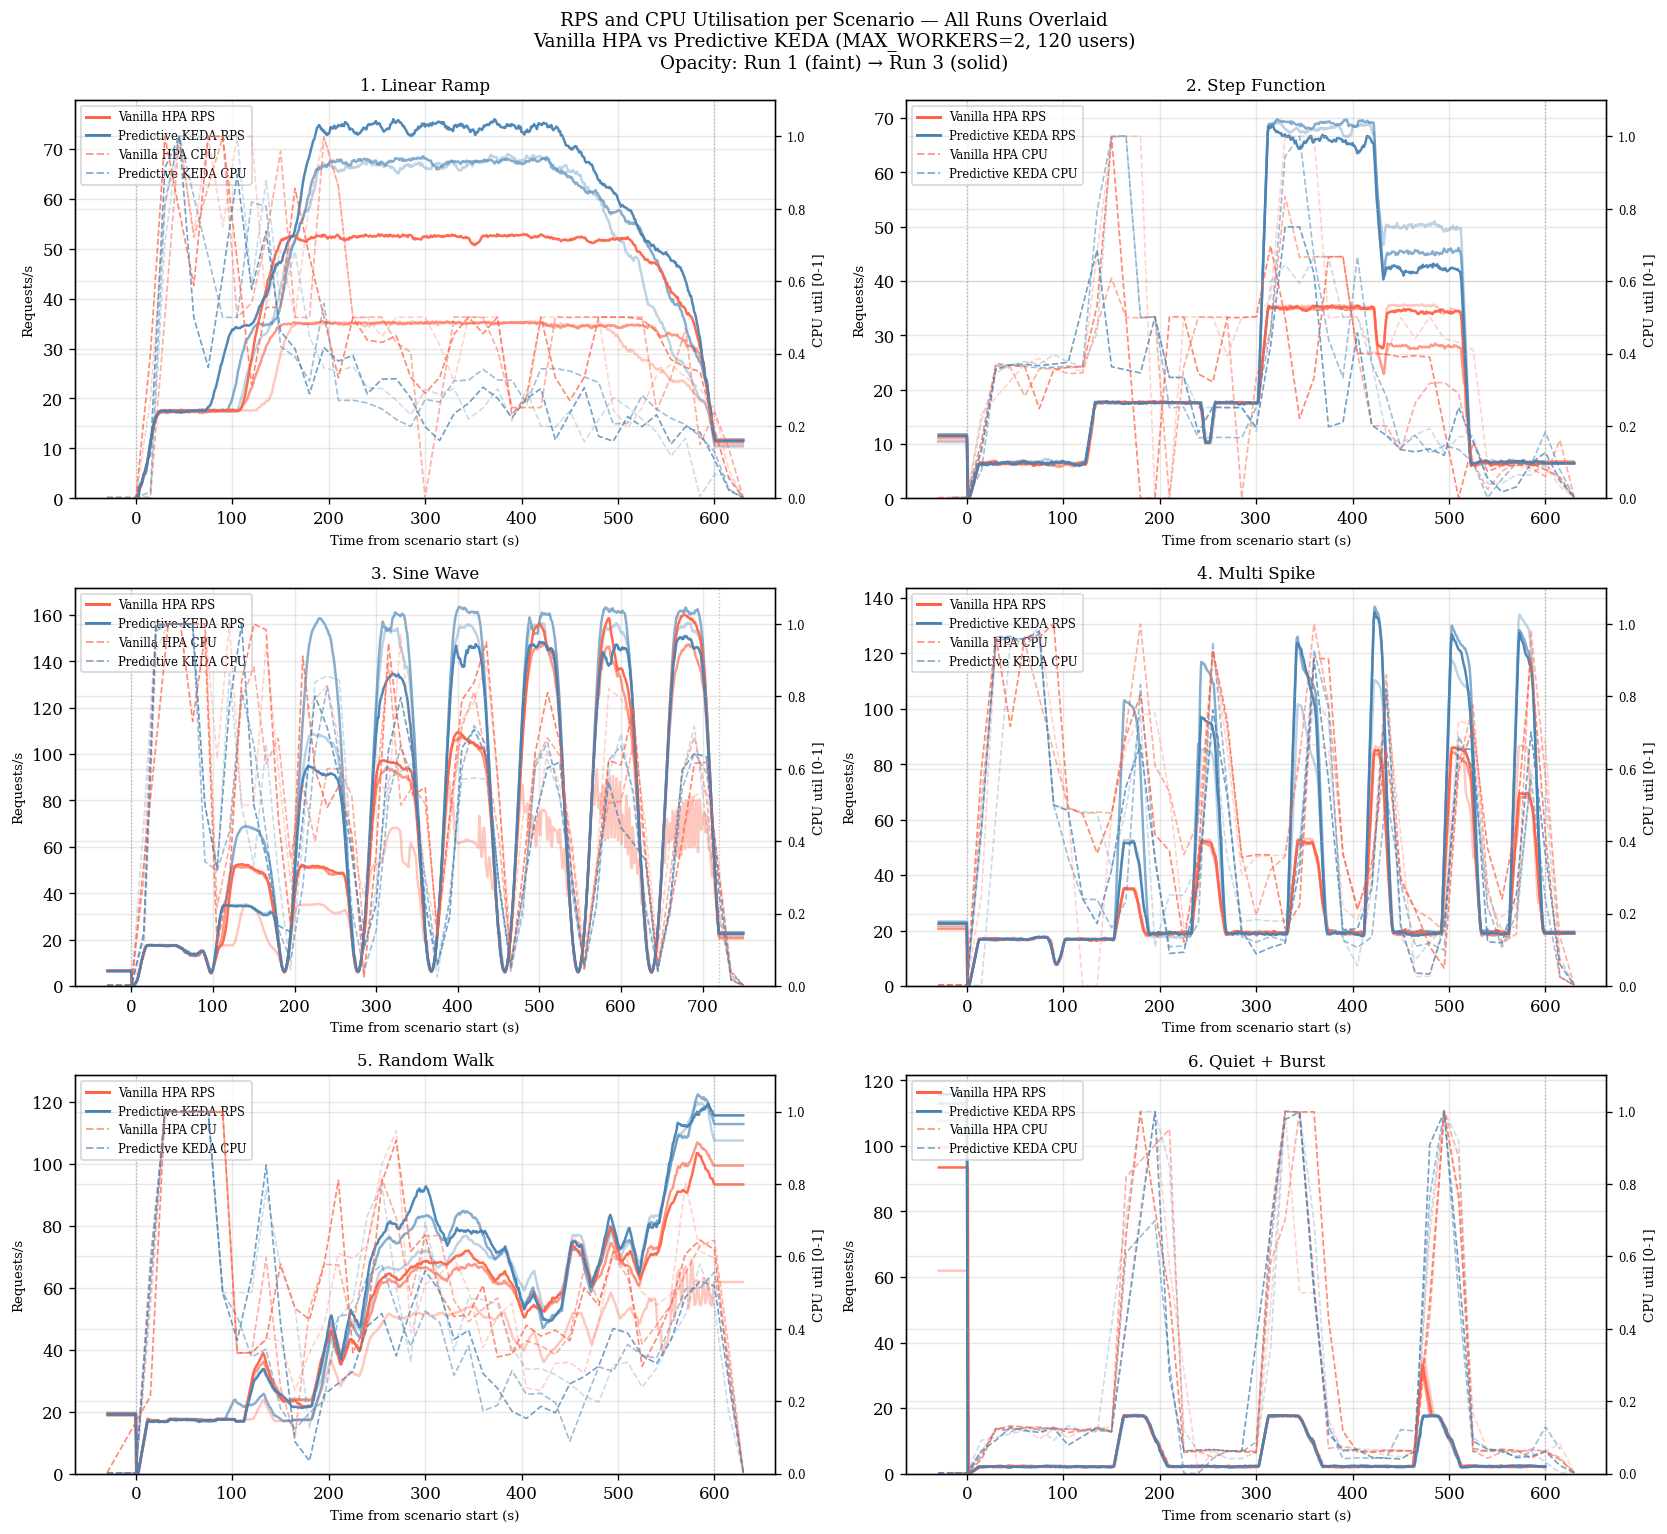

Saved: notebooks/stat_rps_cpu.png


In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
axes = axes.flatten()
fig.suptitle(
    'RPS and CPU Utilisation per Scenario — All Runs Overlaid\n'
    'Vanilla HPA vs Predictive KEDA (MAX_WORKERS=2, 120 users)\n'
    'Opacity: Run 1 (faint) → Run 3 (solid)',
    fontsize=11,
)

for i, scenario in enumerate(SCENARIO_NAMES):
    ax  = axes[i]
    ax2 = ax.twinx()

    for run_idx, run in enumerate(RUNS):
        alpha = RUN_ALPHAS[run_idx]
        for round_key, color in [(run['hpa'], COLOR_HPA), (run['keda'], COLOR_KEDA)]:
            full, _ = slice_scenario(hist_raw[round_key], scenario, round_key)
            if not full.empty:
                ax.plot(full['t'], full['Requests/s'], color=color,
                        linewidth=1.5, alpha=alpha, zorder=3)
            ts_info = timestamps[round_key][scenario]
            start, end = ts_info['start_unix'], ts_info['end_unix']
            cpu_df = add_sec(prom_range(CPU_UTIL_Q, start - IDLE_PAD_S, end + IDLE_PAD_S), start)
            if not cpu_df.empty:
                ax2.plot(cpu_df['sec'], cpu_df['value'], color=color,
                         linewidth=1.0, linestyle='--', alpha=alpha * 0.8, zorder=2)

    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
    dur = (timestamps[RUNS[0]['hpa']][scenario]['end_unix']
           - timestamps[RUNS[0]['hpa']][scenario]['start_unix'])
    ax.axvline(dur, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.set_title(scenario, fontsize=10)
    ax.set_xlabel('Time from scenario start (s)', fontsize=8)
    ax.set_ylabel('Requests/s', fontsize=8)
    ax.set_ylim(bottom=0)
    ax2.set_ylabel('CPU util [0-1]', fontsize=8)
    ax2.set_ylim(0, 1.1)
    ax2.tick_params(labelsize=7)

    handles = [
        Line2D([0],[0], color=COLOR_HPA,  lw=1.8, label=f'{LABEL_HPA} RPS'),
        Line2D([0],[0], color=COLOR_KEDA, lw=1.8, label=f'{LABEL_KEDA} RPS'),
        Line2D([0],[0], color=COLOR_HPA,  lw=1.2, ls='--', alpha=0.6, label=f'{LABEL_HPA} CPU'),
        Line2D([0],[0], color=COLOR_KEDA, lw=1.2, ls='--', alpha=0.6, label=f'{LABEL_KEDA} CPU'),
    ]
    ax.legend(handles=handles, fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig('../notebooks/stat_rps_cpu.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/stat_rps_cpu.png')

---
## 2 — Scale-Up Lag

Scale-up lag = seconds from scenario start (t=0) to first increase in `replicas_ready`.  
Left chart: mean ± std per scenario with individual run markers.  
Right chart: KEDA advantage (HPA lag − KEDA lag).

In [9]:
def measure_scaleup_lag(replicas_df):
    if replicas_df.empty:
        return None
    df = replicas_df[replicas_df['sec'] >= 0].copy()
    if df.empty:
        return None
    init = df['value'].iloc[0]
    scale_rows = df[df['value'] > init]
    if scale_rows.empty:
        return None
    return round(float(scale_rows['sec'].iloc[0]))

lag_hpa_per_run  = []
lag_keda_per_run = []

for run in RUNS:
    h_lags, k_lags = [], []
    for scenario in SCENARIO_NAMES:
        dh = fetch_scenario(run['hpa'],  scenario)
        dk = fetch_scenario(run['keda'], scenario)
        h_lags.append(measure_scaleup_lag(dh['replicas']))
        k_lags.append(measure_scaleup_lag(dk['replicas']))
    lag_hpa_per_run.append(h_lags)
    lag_keda_per_run.append(k_lags)

h_lag_means, h_lag_stds = agg_runs(lag_hpa_per_run)
k_lag_means, k_lag_stds = agg_runs(lag_keda_per_run)
adv_means = h_lag_means - k_lag_means
adv_per_run = [
    [h - k if h is not None and k is not None else None
     for h, k in zip(lag_hpa_per_run[r], lag_keda_per_run[r])]
    for r in range(N_RUNS)
]
adv_means_agg, adv_stds_agg = agg_runs(adv_per_run)

print(f'{"Scenario":<22}  {"HPA μ±σ (s)":>14}  {"KEDA μ±σ (s)":>15}  {"Adv μ±σ (s)":>14}')
print('-' * 73)
for i, scenario in enumerate(SCENARIO_NAMES):
    print(f'{scenario:<22}  {h_lag_means[i]:>5.0f} ± {h_lag_stds[i]:<5.0f}'
          f'  {k_lag_means[i]:>5.0f} ± {k_lag_stds[i]:<6.0f}'
          f'  +{adv_means_agg[i]:>3.0f} ± {adv_stds_agg[i]:<4.0f}')
print('-' * 73)
print(f'{"Average":<22}  {h_lag_means.mean():>5.0f}            '
      f'  {k_lag_means.mean():>5.0f}             '
      f'  +{adv_means_agg.mean():>3.0f}')

Scenario                   HPA μ±σ (s)     KEDA μ±σ (s)     Adv μ±σ (s)
-------------------------------------------------------------------------
1. Linear Ramp            135 ± 0        110 ± 17      + 25 ± 17  
2. Step Function          195 ± 0        180 ± 0       + 15 ± 0   
3. Sine Wave              135 ± 0        110 ± 17      + 25 ± 17  
4. Multi Spike            135 ± 0        100 ± 17      + 35 ± 17  
5. Random Walk            135 ± 0        110 ± 17      + 25 ± 17  
6. Quiet + Burst          255 ± 0        230 ± 17      + 25 ± 17  
-------------------------------------------------------------------------
Average                   165                140               + 25


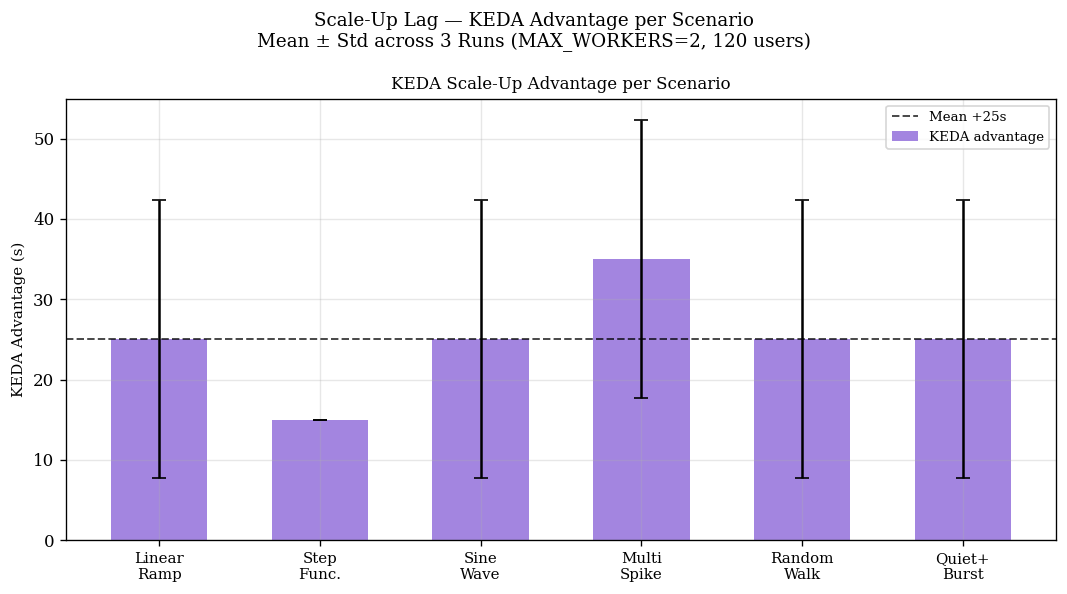

Saved: notebooks/stat_scaleup_lag.png


In [10]:
x = np.arange(len(SCENARIO_NAMES))

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    f'Scale-Up Lag — KEDA Advantage per Scenario\n'
    f'Mean ± Std across {N_RUNS} Runs (MAX_WORKERS=2, 120 users)',
    fontsize=11,
)

ax.bar(x, adv_means_agg, 0.6, color='mediumpurple', alpha=0.85,
       yerr=adv_stds_agg, capsize=4, error_kw={'linewidth': 1.5}, label='KEDA advantage')
ax.axhline(adv_means_agg.mean(), ls='--', lw=1.2, color='black', alpha=0.7,
           label=f'Mean +{adv_means_agg.mean():.0f}s')
ax.set_xticks(x)
ax.set_xticklabels(SHORT_NAMES, fontsize=9)
ax.set_ylabel('KEDA Advantage (s)')
ax.set_title('KEDA Scale-Up Advantage per Scenario')
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../notebooks/stat_scaleup_lag.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/stat_scaleup_lag.png')

---
## 3 — CPU Utilisation

Per-pod CPU utilisation [0, 1] averaged over each scenario window.  
Bar = mean across runs. Error bar = std. Markers = individual run values.

=== CPU Utilisation [0-1]: mean ± std across runs ===
Scenario                     HPA μ±σ       KEDA μ±σ     HPA >50% μ±σ     KEDA >50% μ±σ       Δ μ
----------------------------------------------------------------------------------------------------
1. Linear Ramp          0.487±0.032   0.354±0.021     48.9%±11.0 %      18.1%±5.4  %    -27.3%
2. Step Function        0.377±0.066   0.326±0.036     29.3%±10.9 %      19.7%±7.0  %    -13.5%
3. Sine Wave            0.534±0.033   0.458±0.013     56.6%±1.2  %      46.9%±2.0  %    -14.4%
4. Multi Spike          0.499±0.025   0.393±0.007     43.8%±4.2  %      33.6%±1.0  %    -21.3%
5. Random Walk          0.541±0.011   0.417±0.052     48.7%±2.1  %      28.0%±5.6  %    -22.9%
6. Quiet + Burst        0.260±0.031   0.255±0.034     20.8%±2.1  %      21.0%±3.5  %     -2.0%
----------------------------------------------------------------------------------------------------
Overall                 0.450           0.367              41.4%             

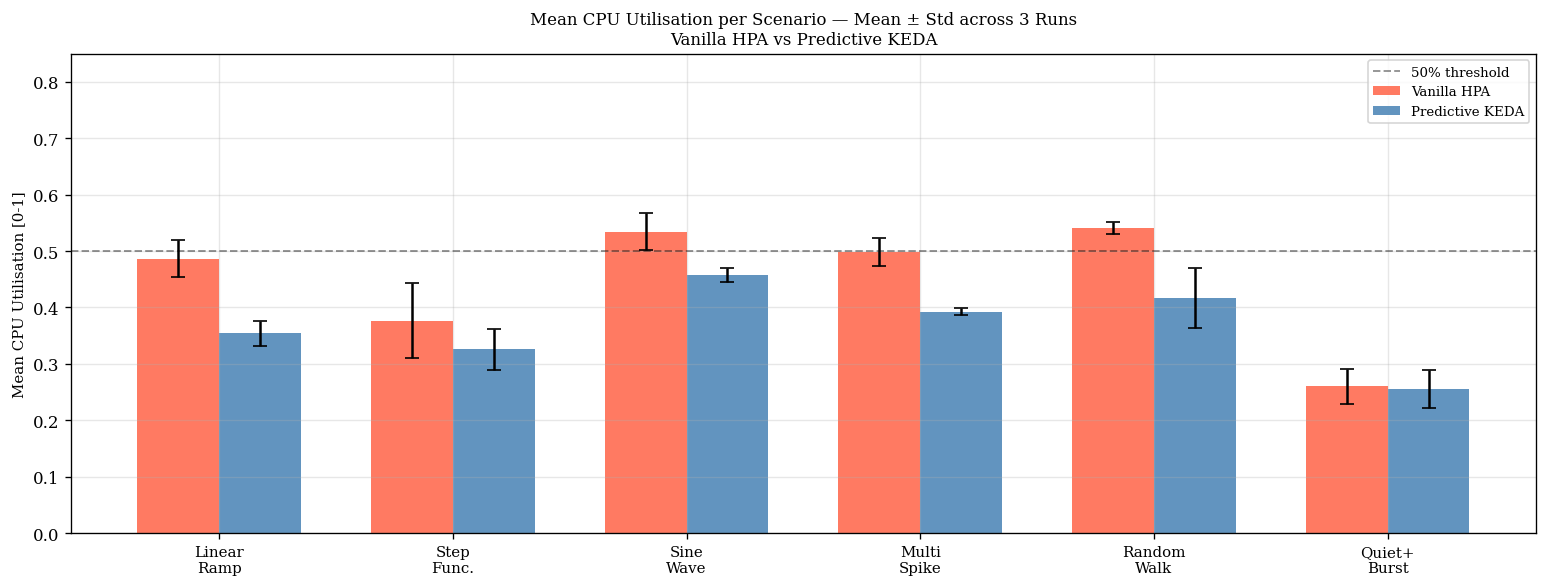

Saved: notebooks/stat_cpu_saturation.png


In [11]:
cpu_hpa_per_run  = []
cpu_keda_per_run = []
sat_hpa_per_run  = []
sat_keda_per_run = []

for run in RUNS:
    h_means, k_means, h_sats, k_sats = [], [], [], []
    for scenario in SCENARIO_NAMES:
        for round_key, means_list, sats_list in [
            (run['hpa'],  h_means, h_sats),
            (run['keda'], k_means, k_sats),
        ]:
            ts_info = timestamps[round_key][scenario]
            start, end = ts_info['start_unix'], ts_info['end_unix']
            df = prom_range(CPU_UTIL_Q, start, end)
            vals = df['value'].values if not df.empty else np.array([np.nan])
            means_list.append(float(np.nanmean(vals)))
            sats_list.append(float((vals > 0.5).mean()))
    cpu_hpa_per_run.append(h_means)
    cpu_keda_per_run.append(k_means)
    sat_hpa_per_run.append(h_sats)
    sat_keda_per_run.append(k_sats)

h_cpu_means, h_cpu_stds = agg_runs(cpu_hpa_per_run)
k_cpu_means, k_cpu_stds = agg_runs(cpu_keda_per_run)
h_sat_means, h_sat_stds = agg_runs(sat_hpa_per_run)
k_sat_means, k_sat_stds = agg_runs(sat_keda_per_run)
delta_cpu = (k_cpu_means - h_cpu_means) / h_cpu_means * 100

print('=== CPU Utilisation [0-1]: mean ± std across runs ===')
print(f'{"Scenario":<22}  {"HPA μ±σ":>12}  {"KEDA μ±σ":>13}  {"HPA >50% μ±σ":>15}  {"KEDA >50% μ±σ":>16}  {"Δ μ":>8}')
print('-' * 100)
for i, scenario in enumerate(SCENARIO_NAMES):
    print(f'{scenario:<22}  {h_cpu_means[i]:>5.3f}±{h_cpu_stds[i]:<5.3f}  '
          f'{k_cpu_means[i]:>6.3f}±{k_cpu_stds[i]:<5.3f}  '
          f'{h_sat_means[i]*100:>7.1f}%±{h_sat_stds[i]*100:<5.1f}%  '
          f'{k_sat_means[i]*100:>8.1f}%±{k_sat_stds[i]*100:<5.1f}%  '
          f'{delta_cpu[i]:>+7.1f}%')
print('-' * 100)
print(f'{"Overall":<22}  {h_cpu_means.mean():>5.3f}          '
      f'{k_cpu_means.mean():>6.3f}           '
      f'{h_sat_means.mean()*100:>7.1f}%           '
      f'{k_sat_means.mean()*100:>8.1f}%           '
      f'{delta_cpu.mean():>+7.1f}%')

x  = np.arange(len(SCENARIO_NAMES))
wb = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - wb/2, h_cpu_means, wb, color=COLOR_HPA,  alpha=0.85,
       yerr=h_cpu_stds, capsize=4, error_kw={'linewidth': 1.5}, label=LABEL_HPA)
ax.bar(x + wb/2, k_cpu_means, wb, color=COLOR_KEDA, alpha=0.85,
       yerr=k_cpu_stds, capsize=4, error_kw={'linewidth': 1.5}, label=LABEL_KEDA)
ax.axhline(0.5, ls='--', lw=1.2, color='black', alpha=0.4, label='50% threshold')
ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES, fontsize=9)
ax.set_ylabel('Mean CPU Utilisation [0-1]')
ax.set_title(f'Mean CPU Utilisation per Scenario — Mean ± Std across {N_RUNS} Runs\n'
             'Vanilla HPA vs Predictive KEDA')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../notebooks/stat_cpu_saturation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/stat_cpu_saturation.png')

---
## 4 — Latency

Medians computed over the active load window (Requests/s > 0.5) per scenario per run.  
Bar = mean across runs. Error bar = std. Markers = individual run values.

In [12]:
def collect_latency_for_run(run: dict) -> pd.DataFrame:
    rows = []
    for scenario in SCENARIO_NAMES:
        _, act_h = slice_scenario(hist_raw[run['hpa']],  scenario, run['hpa'])
        _, act_k = slice_scenario(hist_raw[run['keda']], scenario, run['keda'])
        rows.append({
            'Scenario':  scenario,
            'hpa_p50':  _med(act_h, '50%'), 'keda_p50': _med(act_k, '50%'),
            'hpa_p95':  _med(act_h, '95%'), 'keda_p95': _med(act_k, '95%'),
            'hpa_p99':  _med(act_h, '99%'), 'keda_p99': _med(act_k, '99%'),
        })
    return pd.DataFrame(rows)

lat_per_run = [collect_latency_for_run(run) for run in RUNS]

print('Latency collected.')
for r_idx, (run, df) in enumerate(zip(RUNS, lat_per_run)):
    print(f'\n{run["label"]}:')
    print(df[['Scenario', 'hpa_p50', 'keda_p50', 'hpa_p95', 'keda_p95']].to_string(index=False))

Latency collected.

Run 1 (mw2_2):
        Scenario  hpa_p50  keda_p50  hpa_p95  keda_p95
  1. Linear Ramp     2200       600     5500      4700
2. Step Function     2100       590     5500      4900
    3. Sine Wave     1500       540     5500      4800
  4. Multi Spike      730       250     5400      4600
  5. Random Walk      720       270     5400      4600
6. Quiet + Burst      690       250     5400      4500

Run 2 (mw2_3):
        Scenario  hpa_p50  keda_p50  hpa_p95  keda_p95
  1. Linear Ramp     1900       960     5000      4200
2. Step Function     1500       770     5300      4300
    3. Sine Wave     1200       380     5200      4200
  4. Multi Spike      530       210     5000      4100
  5. Random Walk      550       220     5000      4000
6. Quiet + Burst      420       200     5000      3900

Run 3 (mw2_4):
        Scenario  hpa_p50  keda_p50  hpa_p95  keda_p95
  1. Linear Ramp      850       550     4300      3800
2. Step Function      820       465     5200      390

In [13]:
def latency_bar_chart(h_col, k_col, pct_label, outfile):
    """Bar chart (mean ± std) + table for one latency percentile."""
    h_vals_per_run = np.array([[df[h_col].iloc[i] for df in lat_per_run]
                                for i in range(len(SCENARIO_NAMES))], dtype=float)
    k_vals_per_run = np.array([[df[k_col].iloc[i] for df in lat_per_run]
                                for i in range(len(SCENARIO_NAMES))], dtype=float)
    h_means = h_vals_per_run.mean(axis=1)
    h_stds  = h_vals_per_run.std(axis=1, ddof=1 if N_RUNS > 1 else 0)
    k_means = k_vals_per_run.mean(axis=1)
    k_stds  = k_vals_per_run.std(axis=1, ddof=1 if N_RUNS > 1 else 0)

    # Overall: mean of per-run medians (consistent with cell-s4-combined)
    overall_h = int(np.mean([df[h_col].median() for df in lat_per_run]))
    overall_k = int(np.mean([df[k_col].median() for df in lat_per_run]))

    x  = np.arange(len(SCENARIO_NAMES))
    wb = 0.35
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - wb/2, h_means, wb, color=COLOR_HPA,  alpha=0.85,
           yerr=h_stds, capsize=4, error_kw={'linewidth': 1.5}, label=LABEL_HPA)
    ax.bar(x + wb/2, k_means, wb, color=COLOR_KEDA, alpha=0.85,
           yerr=k_stds, capsize=4, error_kw={'linewidth': 1.5}, label=LABEL_KEDA)

    for xi, (hv, kv, he, ke) in enumerate(zip(h_means, k_means, h_stds, k_stds)):
        for v, err, xoff, color in [(hv, he, -wb/2, COLOR_HPA), (kv, ke, wb/2, COLOR_KEDA)]:
            lbl = f'{v/1000:.1f}s' if v >= 1000 else f'{v:.0f}'
            ax.text(x[xi] + xoff, v + err + max(v * 0.02, 20), lbl,
                    ha='center', va='bottom', fontsize=7, color=color)

    ax.axhline(overall_h, ls='--', lw=1.2, color=COLOR_HPA,  alpha=0.7,
               label=f'HPA mean {overall_h} ms')
    ax.axhline(overall_k, ls='--', lw=1.2, color=COLOR_KEDA, alpha=0.7,
               label=f'KEDA mean {overall_k} ms')
    ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES, fontsize=9)
    ax.set_ylabel(f'{pct_label} Latency (ms)')
    ax.set_title(f'{pct_label} Latency — Mean ± Std across {N_RUNS} Runs\n'
                 'Vanilla HPA vs Predictive KEDA')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(f'../notebooks/{outfile}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: notebooks/{outfile}')
    print(f'Overall (mean): HPA {overall_h} ms | KEDA {overall_k} ms | '
          f'Δ = {overall_k - overall_h:+d} ms ({(overall_k-overall_h)/overall_h*100:+.1f}%)')

    tbl = pd.DataFrame({
        'Scenario':                        SCENARIO_NAMES,
        f'HPA {pct_label} μ±σ': [f'{h_means[i]:.0f} ± {h_stds[i]:.0f}' for i in range(len(SCENARIO_NAMES))],
        f'KEDA {pct_label} μ±σ': [f'{k_means[i]:.0f} ± {k_stds[i]:.0f}' for i in range(len(SCENARIO_NAMES))],
        'Δ (ms)': [f'{k_means[i]-h_means[i]:+.0f}'                          for i in range(len(SCENARIO_NAMES))],
        'Δ (%)':  [f'{(k_means[i]-h_means[i])/h_means[i]*100:+.1f}%'        for i in range(len(SCENARIO_NAMES))],
    })
    print()
    print(tbl.to_string(index=False))
    return h_means, h_stds, k_means, k_stds, overall_h, overall_k

print('Helper latency_bar_chart defined.')

Helper latency_bar_chart defined.


### P50 Latency

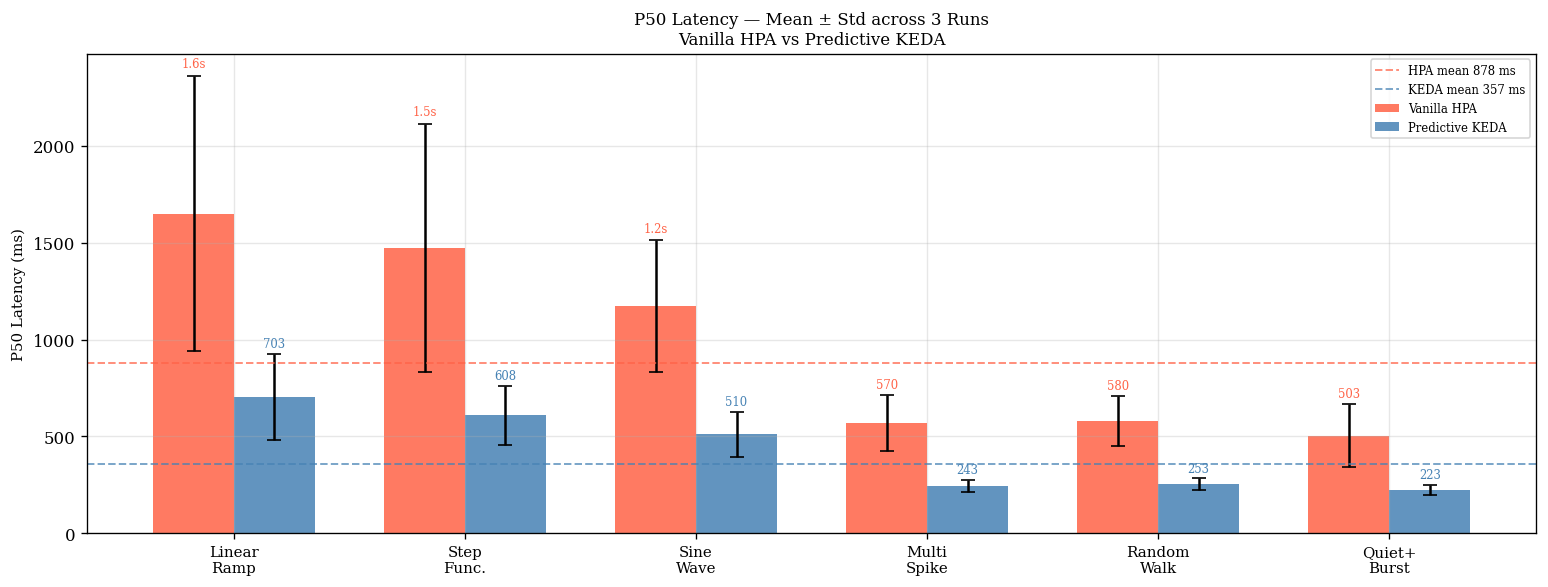

Saved: notebooks/stat_p50_bars.png
Overall (mean): HPA 878 ms | KEDA 357 ms | Δ = -521 ms (-59.3%)

        Scenario HPA P50 μ±σ KEDA P50 μ±σ Δ (ms)  Δ (%)
  1. Linear Ramp  1650 ± 709    703 ± 224   -947 -57.4%
2. Step Function  1473 ± 640    608 ± 153   -865 -58.7%
    3. Sine Wave  1173 ± 341    510 ± 118   -663 -56.5%
  4. Multi Spike   570 ± 144     243 ± 31   -327 -57.3%
  5. Random Walk   580 ± 128     253 ± 29   -327 -56.3%
6. Quiet + Burst   503 ± 162     223 ± 25   -280 -55.6%


In [14]:
h50_means, h50_stds, k50_means, k50_stds, overall_h50, overall_k50 = \
    latency_bar_chart('hpa_p50', 'keda_p50', 'P50', 'stat_p50_bars.png')

### P95 Latency

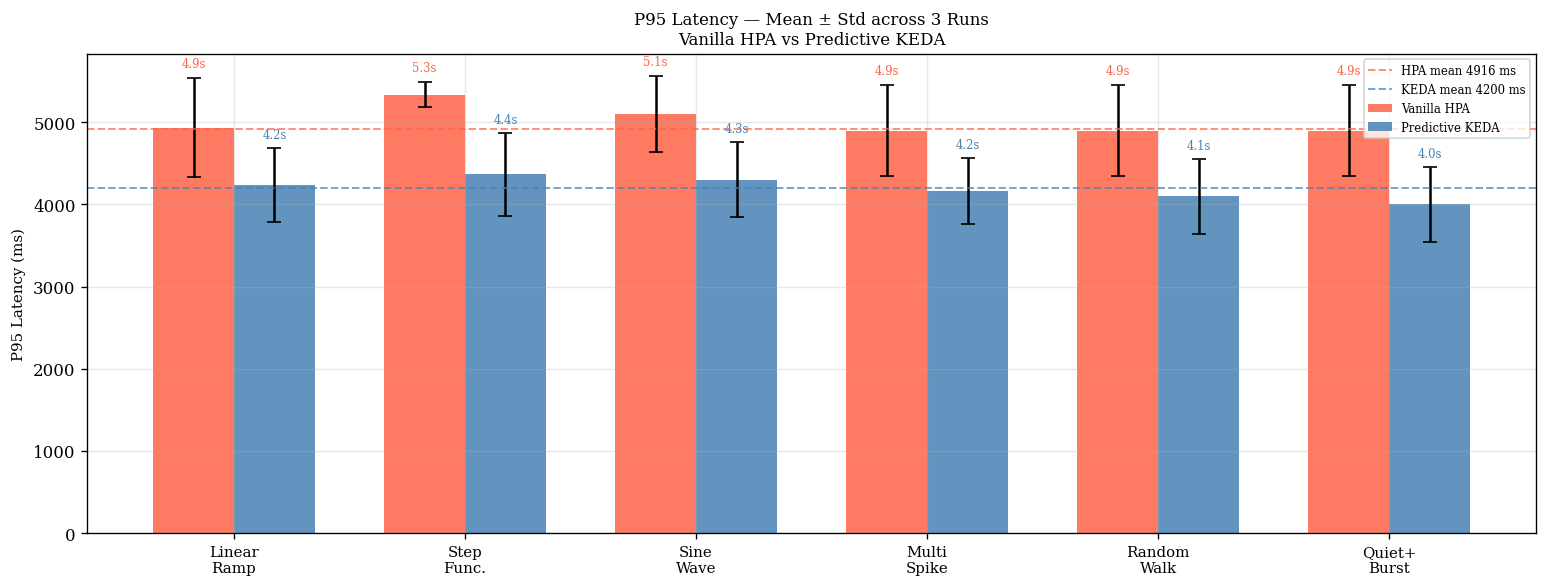

Saved: notebooks/stat_p95_bars.png
Overall (mean): HPA 4916 ms | KEDA 4200 ms | Δ = -716 ms (-14.6%)

        Scenario HPA P95 μ±σ KEDA P95 μ±σ Δ (ms)  Δ (%)
  1. Linear Ramp  4933 ± 603   4233 ± 451   -700 -14.2%
2. Step Function  5333 ± 153   4367 ± 503   -967 -18.1%
    3. Sine Wave  5100 ± 458   4300 ± 458   -800 -15.7%
  4. Multi Spike  4900 ± 557   4167 ± 404   -733 -15.0%
  5. Random Walk  4900 ± 557   4100 ± 458   -800 -16.3%
6. Quiet + Burst  4900 ± 557   4000 ± 458   -900 -18.4%


In [15]:
h95_means, h95_stds, k95_means, k95_stds, overall_h95, overall_k95 = \
    latency_bar_chart('hpa_p95', 'keda_p95', 'P95', 'stat_p95_bars.png')

### P99 Latency

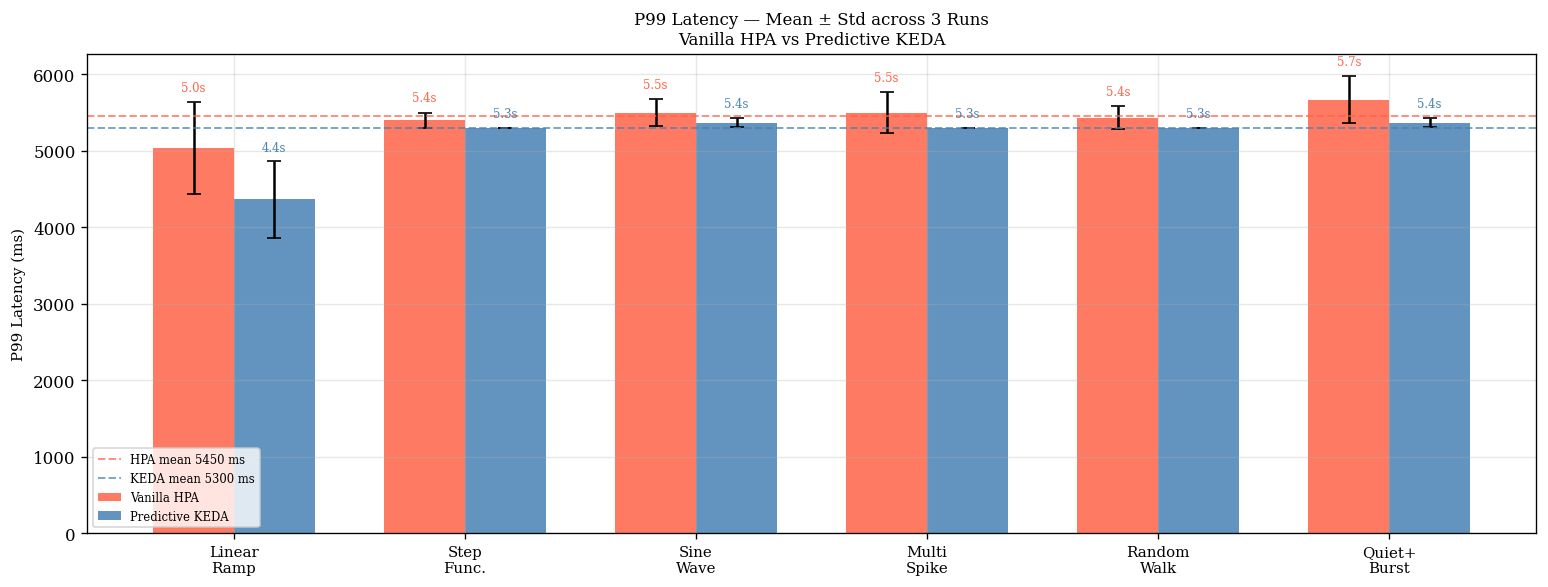

Saved: notebooks/stat_p99_bars.png
Overall (mean): HPA 5450 ms | KEDA 5300 ms | Δ = -150 ms (-2.8%)

        Scenario HPA P99 μ±σ KEDA P99 μ±σ Δ (ms)  Δ (%)
  1. Linear Ramp  5033 ± 603   4367 ± 503   -667 -13.2%
2. Step Function  5400 ± 100     5300 ± 0   -100  -1.9%
    3. Sine Wave  5500 ± 173    5367 ± 58   -133  -2.4%
  4. Multi Spike  5500 ± 265     5300 ± 0   -200  -3.6%
  5. Random Walk  5433 ± 153     5300 ± 0   -133  -2.5%
6. Quiet + Burst  5667 ± 306    5367 ± 58   -300  -5.3%


In [16]:
h99_means, h99_stds, k99_means, k99_stds, overall_h99, overall_k99 = \
    latency_bar_chart('hpa_p99', 'keda_p99', 'P99', 'stat_p99_bars.png')

### Combined Latency: Overall Bars + Distribution across Runs

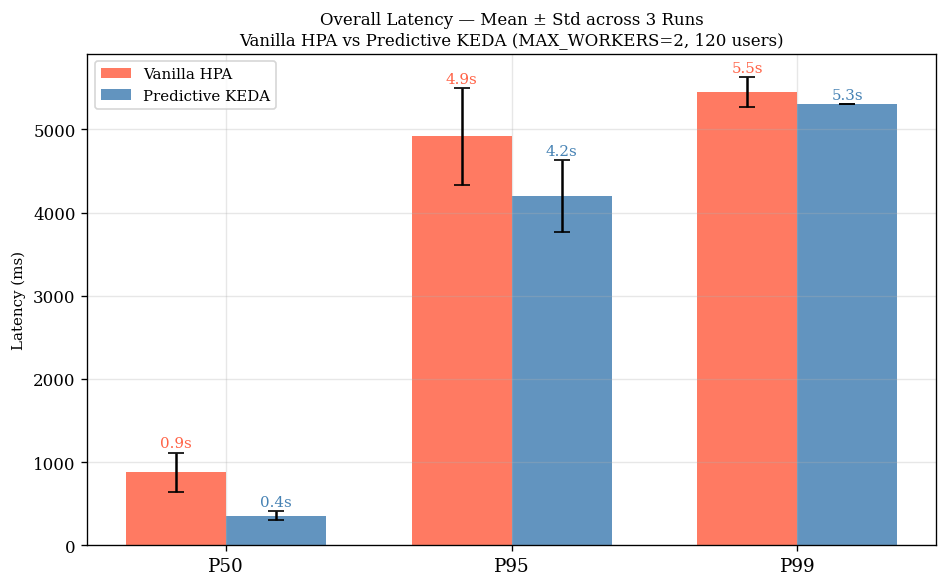

Saved: notebooks/stat_latency_overall_bar.png

                   HPA μ±σ           KEDA μ±σ             Δ μ
--------------------------------------------------------------
P50          878 ± 235    ms     358 ± 53     ms    -521 ms (-59.3%)
P95         4917 ± 580    ms    4200 ± 427    ms    -717 ms (-14.6%)
P99         5450 ± 180    ms    5300 ± 0      ms    -150 ms (-2.8%)


In [17]:
pcts = ['P50', 'P95', 'P99']
h_cols = ['hpa_p50', 'hpa_p95', 'hpa_p99']
k_cols = ['keda_p50', 'keda_p95', 'keda_p99']

# One summary value per run = median across 6 scenarios
h_run_ovr = np.array([[df[c].median() for c in h_cols] for df in lat_per_run], dtype=float)
k_run_ovr = np.array([[df[c].median() for c in k_cols] for df in lat_per_run], dtype=float)

ddof = 1 if N_RUNS > 1 else 0
h_ovr_means = h_run_ovr.mean(axis=0)
h_ovr_stds  = h_run_ovr.std(axis=0, ddof=ddof)
k_ovr_means = k_run_ovr.mean(axis=0)
k_ovr_stds  = k_run_ovr.std(axis=0, ddof=ddof)

xi = np.arange(len(pcts))
wb = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(xi - wb/2, h_ovr_means, wb, color=COLOR_HPA,  alpha=0.85,
       yerr=h_ovr_stds, capsize=5, error_kw={'linewidth': 1.5}, label=LABEL_HPA)
ax.bar(xi + wb/2, k_ovr_means, wb, color=COLOR_KEDA, alpha=0.85,
       yerr=k_ovr_stds, capsize=5, error_kw={'linewidth': 1.5}, label=LABEL_KEDA)
for xii, (hv, kv, he, ke) in enumerate(zip(h_ovr_means, k_ovr_means, h_ovr_stds, k_ovr_stds)):
    ax.text(xi[xii] - wb/2, hv + he + 30, f'{hv/1000:.1f}s',
            ha='center', va='bottom', fontsize=9, color=COLOR_HPA)
    ax.text(xi[xii] + wb/2, kv + ke + 30, f'{kv/1000:.1f}s',
            ha='center', va='bottom', fontsize=9, color=COLOR_KEDA)
ax.set_xticks(xi)
ax.set_xticklabels(pcts, fontsize=11)
ax.set_ylabel('Latency (ms)')
ax.set_title(f'Overall Latency — Mean ± Std across {N_RUNS} Runs\n'
             'Vanilla HPA vs Predictive KEDA (MAX_WORKERS=2, 120 users)')
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../notebooks/stat_latency_overall_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/stat_latency_overall_bar.png')

print(f'\n{"":8}  {"HPA μ±σ":>16}  {"KEDA μ±σ":>17}  {"Δ μ":>14}')
print('-' * 62)
for pct, hm, hs, km, ks in zip(pcts, h_ovr_means, h_ovr_stds, k_ovr_means, k_ovr_stds):
    delta = km - hm
    print(f'{pct:<8}  {hm:>6.0f} ± {hs:<6.0f} ms  {km:>6.0f} ± {ks:<6.0f} ms  '
          f'{delta:>+6.0f} ms ({delta/hm*100:+.1f}%)')

---
## 5 — Requests per Second

Mean RPS over the active load window (Requests/s > 0.5) per scenario per run.

Scenario                       HPA μ±σ         KEDA μ±σ       Δ μ     Δ (%)
--------------------------------------------------------------------------------
1. Linear Ramp          33.91 ± 7.68    51.37 ± 3.76     +17.47    +51.5%
2. Step Function        19.24 ± 0.67    27.90 ± 0.80      +8.65    +45.0%
3. Sine Wave            56.98 ± 13.89   77.66 ± 5.79     +20.68    +36.3%
4. Multi Spike          29.01 ± 0.38    40.05 ± 2.87     +11.04    +38.1%
5. Random Walk          47.32 ± 7.76    56.16 ± 1.21      +8.84    +18.7%
6. Quiet + Burst         5.79 ± 0.08     5.39 ± 0.11      -0.40     -6.9%
--------------------------------------------------------------------------------
Overall mean                     32.04            43.09    +11.05    +34.5%


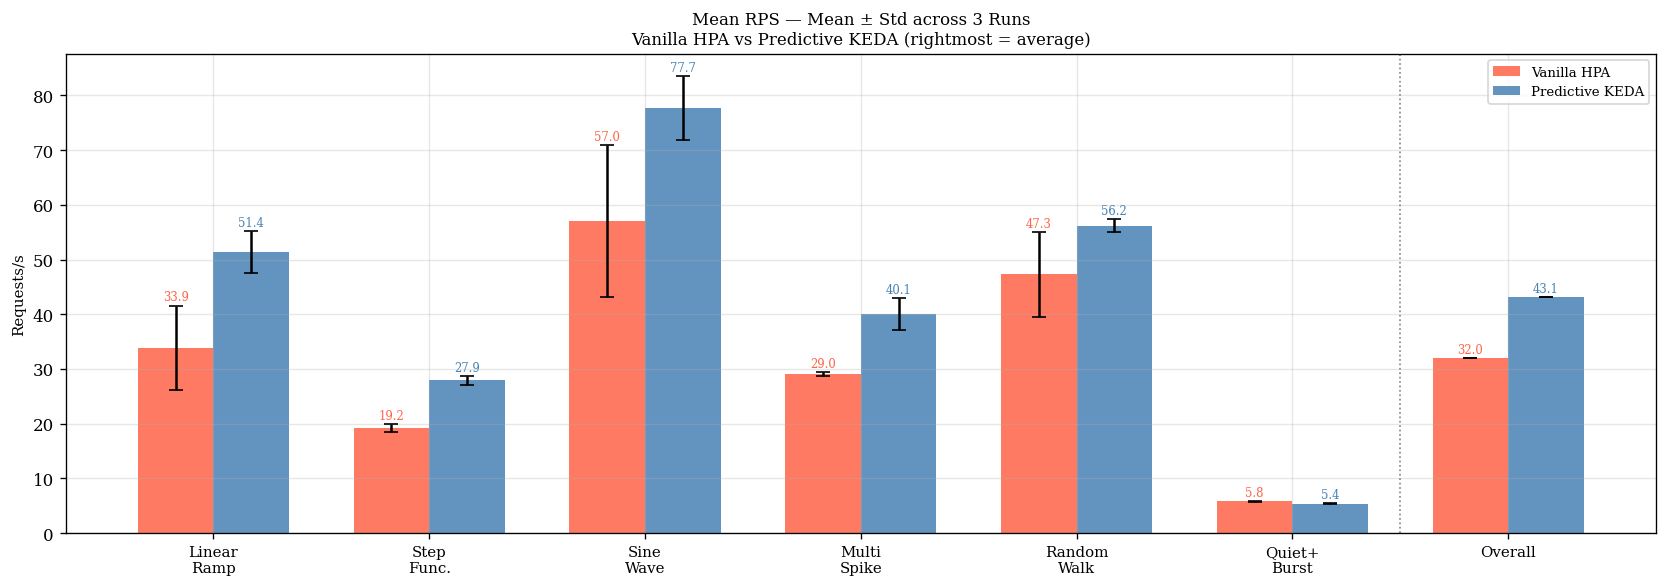

Saved: notebooks/stat_rps_bars.png


In [18]:
def collect_rps_for_run(run: dict) -> pd.DataFrame:
    rows = []
    for scenario in SCENARIO_NAMES:
        _, act_h = slice_scenario(hist_raw[run['hpa']],  scenario, run['hpa'])
        _, act_k = slice_scenario(hist_raw[run['keda']], scenario, run['keda'])
        rows.append({
            'Scenario': scenario,
            'hpa_rps':  act_h['Requests/s'].mean() if not act_h.empty else 0.0,
            'keda_rps': act_k['Requests/s'].mean() if not act_k.empty else 0.0,
        })
    return pd.DataFrame(rows)

rps_per_run = [collect_rps_for_run(run) for run in RUNS]

h_rps_per_run = np.array([[df['hpa_rps'].iloc[i]  for df in rps_per_run]
                           for i in range(len(SCENARIO_NAMES))], dtype=float)
k_rps_per_run = np.array([[df['keda_rps'].iloc[i] for df in rps_per_run]
                           for i in range(len(SCENARIO_NAMES))], dtype=float)
h_rps_means = h_rps_per_run.mean(axis=1)
h_rps_stds  = h_rps_per_run.std(axis=1, ddof=1 if N_RUNS > 1 else 0)
k_rps_means = k_rps_per_run.mean(axis=1)
k_rps_stds  = k_rps_per_run.std(axis=1, ddof=1 if N_RUNS > 1 else 0)

h_ov_rps = h_rps_means.mean()
k_ov_rps = k_rps_means.mean()
ov_rps_delta = (k_ov_rps - h_ov_rps) / h_ov_rps * 100

# Table
print(f'{"Scenario":<22}  {"HPA μ±σ":>14}  {"KEDA μ±σ":>15}  {"Δ μ":>8}  {"Δ (%)":>8}')
print('-' * 80)
for i, scenario in enumerate(SCENARIO_NAMES):
    delta = k_rps_means[i] - h_rps_means[i]
    pct   = delta / h_rps_means[i] * 100 if h_rps_means[i] else float('nan')
    print(f'{scenario:<22}  {h_rps_means[i]:>5.2f} ± {h_rps_stds[i]:<5.2f}  '
          f'{k_rps_means[i]:>6.2f} ± {k_rps_stds[i]:<5.2f}  '
          f'{delta:>+8.2f}  {pct:>+7.1f}%')
print('-' * 80)
print(f'{"Overall mean":<22}  {h_ov_rps:>14.2f}  {k_ov_rps:>15.2f}  '
      f'{k_ov_rps-h_ov_rps:>+8.2f}  {ov_rps_delta:>+7.1f}%')

# Bar chart
x_ext  = np.arange(len(SCENARIO_NAMES) + 1)
labels = SHORT_NAMES + ['Overall']
hpa_vals  = list(h_rps_means) + [h_ov_rps]
keda_vals = list(k_rps_means) + [k_ov_rps]
hpa_errs  = list(h_rps_stds)  + [0.0]
keda_errs = list(k_rps_stds)  + [0.0]

wb = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x_ext - wb/2, hpa_vals,  wb, color=COLOR_HPA,  alpha=0.85,
       yerr=hpa_errs,  capsize=4, error_kw={'linewidth': 1.5}, label=LABEL_HPA)
ax.bar(x_ext + wb/2, keda_vals, wb, color=COLOR_KEDA, alpha=0.85,
       yerr=keda_errs, capsize=4, error_kw={'linewidth': 1.5}, label=LABEL_KEDA)
ax.axvline(len(SCENARIO_NAMES) - 0.5, color='gray', linewidth=1.0, linestyle=':')
for xi, (hv, kv, he, ke) in enumerate(zip(hpa_vals, keda_vals, hpa_errs, keda_errs)):
    ax.text(x_ext[xi] - wb/2, hv + he + 0.4, f'{hv:.1f}', ha='center', va='bottom', fontsize=7, color=COLOR_HPA)
    ax.text(x_ext[xi] + wb/2, kv + ke + 0.4, f'{kv:.1f}', ha='center', va='bottom', fontsize=7, color=COLOR_KEDA)
ax.set_xticks(x_ext); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Requests/s')
ax.set_title(f'Mean RPS — Mean ± Std across {N_RUNS} Runs\n'
             'Vanilla HPA vs Predictive KEDA (rightmost = average)')
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../notebooks/stat_rps_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/stat_rps_bars.png')

---
## 6 — Over-Provisioning

Time-weighted mean ready replica count during each scenario window.

Scenario                      HPA μ±σ        KEDA μ±σ   Ratio μ
--------------------------------------------------------------------
1. Linear Ramp           3.54 ± 0.81    9.09 ± 0.72     2.57×
2. Step Function         2.55 ± 0.08    5.09 ± 0.07     2.00×
3. Sine Wave             6.67 ± 0.92   10.93 ± 0.98     1.64×
4. Multi Spike           3.03 ± 0.10    5.98 ± 1.03     1.97×
5. Random Walk           4.88 ± 0.62    8.18 ± 1.22     1.67×
6. Quiet + Burst         1.32 ± 0.06    1.47 ± 0.08     1.11×
--------------------------------------------------------------------
Overall                          3.67            6.79     1.85×


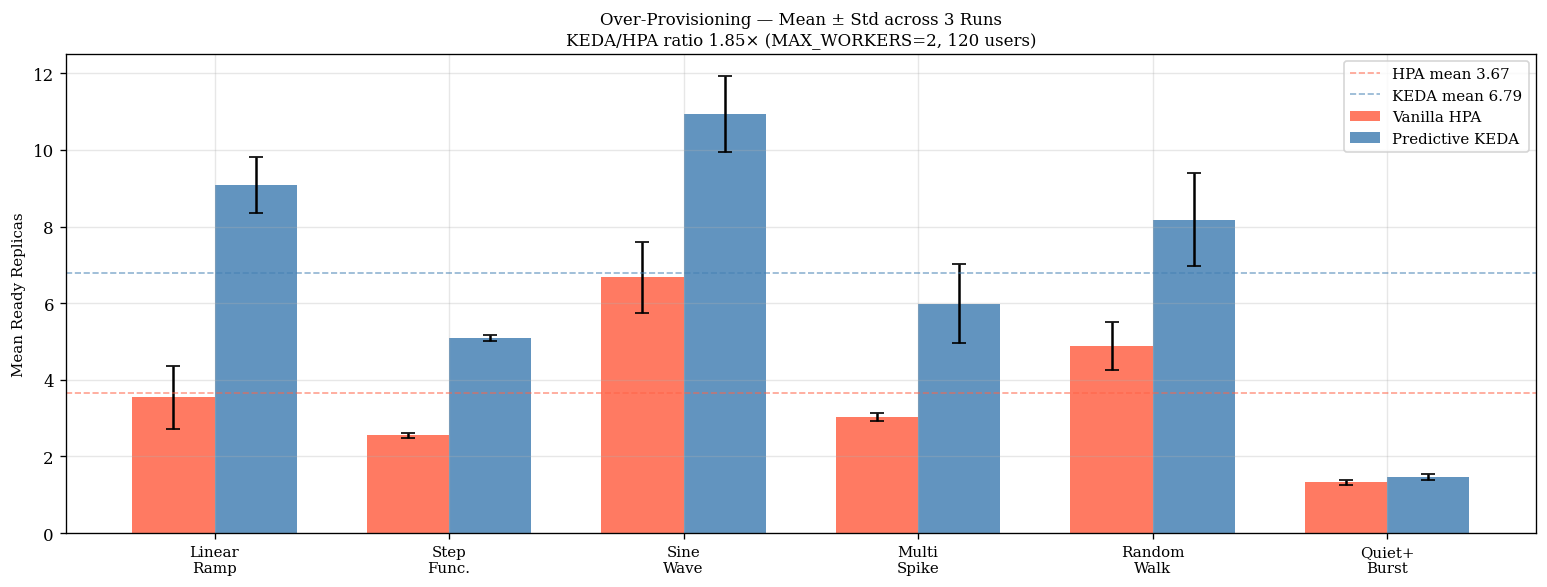

Saved: notebooks/stat_overprovisioning.png


In [19]:
def mean_replicas(replicas_df):
    if replicas_df.empty:
        return None
    df = replicas_df[replicas_df['sec'] >= 0].copy().sort_values('sec').reset_index(drop=True)
    if len(df) < 2:
        return float(df['value'].iloc[0]) if not df.empty else None
    dt = df['sec'].diff().fillna(0)
    return float(np.average(df['value'], weights=dt.clip(lower=0) + 1e-9))

def collect_overprov_for_run(run: dict) -> pd.DataFrame:
    rows = []
    for scenario in SCENARIO_NAMES:
        dh = fetch_scenario(run['hpa'],  scenario)
        dk = fetch_scenario(run['keda'], scenario)
        h_mean = mean_replicas(dh['replicas'])
        k_mean = mean_replicas(dk['replicas'])
        rows.append({
            'Scenario':  scenario,
            'hpa_mean':  h_mean or 0.0,
            'keda_mean': k_mean or 0.0,
            'ratio':     (k_mean / h_mean) if (h_mean and k_mean) else None,
        })
    return pd.DataFrame(rows)

op_per_run = [collect_overprov_for_run(run) for run in RUNS]

h_op_per_run = np.array([[df['hpa_mean'].iloc[i]  for df in op_per_run]
                          for i in range(len(SCENARIO_NAMES))], dtype=float)
k_op_per_run = np.array([[df['keda_mean'].iloc[i] for df in op_per_run]
                          for i in range(len(SCENARIO_NAMES))], dtype=float)
h_op_means = h_op_per_run.mean(axis=1)
h_op_stds  = h_op_per_run.std(axis=1, ddof=1 if N_RUNS > 1 else 0)
k_op_means = k_op_per_run.mean(axis=1)
k_op_stds  = k_op_per_run.std(axis=1, ddof=1 if N_RUNS > 1 else 0)
h_ov_rep = h_op_means.mean()
k_ov_rep = k_op_means.mean()

print(f'{"Scenario":<22}  {"HPA μ±σ":>13}  {"KEDA μ±σ":>14}  {"Ratio μ":>8}')
print('-' * 68)
for i, scenario in enumerate(SCENARIO_NAMES):
    ratio = k_op_means[i] / h_op_means[i] if h_op_means[i] else float('nan')
    print(f'{scenario:<22}  {h_op_means[i]:>5.2f} ± {h_op_stds[i]:<4.2f}  '
          f'{k_op_means[i]:>6.2f} ± {k_op_stds[i]:<4.2f}  {ratio:>7.2f}×')
print('-' * 68)
print(f'{"Overall":<22}  {h_ov_rep:>13.2f}  {k_ov_rep:>14.2f}  {k_ov_rep/h_ov_rep:>7.2f}×')

x  = np.arange(len(SCENARIO_NAMES))
wb = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - wb/2, h_op_means, wb, color=COLOR_HPA,  alpha=0.85,
       yerr=h_op_stds, capsize=4, error_kw={'linewidth': 1.5}, label=LABEL_HPA)
ax.bar(x + wb/2, k_op_means, wb, color=COLOR_KEDA, alpha=0.85,
       yerr=k_op_stds, capsize=4, error_kw={'linewidth': 1.5}, label=LABEL_KEDA)
ax.axhline(h_ov_rep, ls='--', lw=1, color=COLOR_HPA,  alpha=0.6, label=f'HPA mean {h_ov_rep:.2f}')
ax.axhline(k_ov_rep, ls='--', lw=1, color=COLOR_KEDA, alpha=0.6, label=f'KEDA mean {k_ov_rep:.2f}')
ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES, fontsize=9)
ax.set_ylabel('Mean Ready Replicas')
ax.set_title(f'Over-Provisioning — Mean ± Std across {N_RUNS} Runs\n'
             f'KEDA/HPA ratio {k_ov_rep/h_ov_rep:.2f}× (MAX_WORKERS=2, 120 users)')
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('../notebooks/stat_overprovisioning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/stat_overprovisioning.png')

---
## 7 — Overall Summary

Aggregate metrics from clipped scenario windows (idle pauses excluded).  
Each run contributes one value; reported as mean \u00b1 std across runs.

In [20]:
summary_hpa_per_run  = []
summary_keda_per_run = []

for r_idx, run in enumerate(RUNS):
    sh = summary_from_history(hist_clipped[run['hpa']])
    sk = summary_from_history(hist_clipped[run['keda']])
    sh['Requests'] = get_total_from_stats(stats_dfs[run['hpa']],  'Request Count')
    sk['Requests'] = get_total_from_stats(stats_dfs[run['keda']], 'Request Count')
    sh['Failures'] = get_total_from_stats(stats_dfs[run['hpa']],  'Failure Count')
    sk['Failures'] = get_total_from_stats(stats_dfs[run['keda']], 'Failure Count')
    # CPU >50%: mean fraction across scenarios for this run
    sh['CPU >50%'] = float(np.mean(sat_hpa_per_run[r_idx]))
    sk['CPU >50%'] = float(np.mean(sat_keda_per_run[r_idx]))
    # Mean Replicas: time-weighted mean across scenarios for this run
    sh['Mean Replicas'] = float(op_per_run[r_idx]['hpa_mean'].mean())
    sk['Mean Replicas'] = float(op_per_run[r_idx]['keda_mean'].mean())
    summary_hpa_per_run.append(sh)
    summary_keda_per_run.append(sk)

metrics = ['Median (ms)', 'P95 (ms)', 'P99 (ms)', 'Max (ms)',
           'Avg RPS', 'CPU >50%', 'Mean Replicas', 'Requests', 'Failures']

print(f'=== A/B Summary across {N_RUNS} runs: MAX_WORKERS=2, 120 users ===')
print(f'{"Metric":<18}  {"HPA μ±σ":>20}  {"KEDA μ±σ":>21}  {"Δ μ":>16}')
print('-' * 82)

for m in metrics:
    h_vals_m = [s[m] for s in summary_hpa_per_run]
    k_vals_m = [s[m] for s in summary_keda_per_run]
    h_mu, h_sd = np.mean(h_vals_m), np.std(h_vals_m, ddof=1 if N_RUNS > 1 else 0)
    k_mu, k_sd = np.mean(k_vals_m), np.std(k_vals_m, ddof=1 if N_RUNS > 1 else 0)
    delta = k_mu - h_mu
    if m in ('Median (ms)', 'P95 (ms)', 'P99 (ms)', 'Max (ms)') and h_mu:
        delta_str = f'{delta:+.0f} ms ({delta/h_mu*100:+.1f}%)'
        row_h = f'{h_mu:.0f} ± {h_sd:.0f}'
        row_k = f'{k_mu:.0f} ± {k_sd:.0f}'
    elif m == 'Avg RPS' and h_mu:
        delta_str = f'{delta:+.2f} ({delta/h_mu*100:+.1f}%)'
        row_h = f'{h_mu:.2f} ± {h_sd:.2f}'
        row_k = f'{k_mu:.2f} ± {k_sd:.2f}'
    elif m == 'CPU >50%' and h_mu:
        delta_str = f'{delta*100:+.1f}pp ({delta/h_mu*100:+.1f}%)'
        row_h = f'{h_mu*100:.1f}% ± {h_sd*100:.1f}%'
        row_k = f'{k_mu*100:.1f}% ± {k_sd*100:.1f}%'
    elif m == 'Mean Replicas' and h_mu:
        delta_str = f'{delta:+.2f} ({delta/h_mu*100:+.1f}%)'
        row_h = f'{h_mu:.2f} ± {h_sd:.2f}'
        row_k = f'{k_mu:.2f} ± {k_sd:.2f}'
    else:
        delta_str = f'{delta:+.0f}'
        row_h = f'{h_mu:.0f} ± {h_sd:.0f}'
        row_k = f'{k_mu:.0f} ± {k_sd:.0f}'
    print(f'{m:<18}  {row_h:>20}  {row_k:>21}  {delta_str:>16}')

print('-' * 82)
print(f'\nKey findings (μ across {N_RUNS} runs):')
h_p50s = [s['Median (ms)']    for s in summary_hpa_per_run]
k_p50s = [s['Median (ms)']    for s in summary_keda_per_run]
h_p95s = [s['P95 (ms)']       for s in summary_hpa_per_run]
k_p95s = [s['P95 (ms)']       for s in summary_keda_per_run]
h_rpss = [s['Avg RPS']        for s in summary_hpa_per_run]
k_rpss = [s['Avg RPS']        for s in summary_keda_per_run]
h_cpus = [s['CPU >50%']       for s in summary_hpa_per_run]
k_cpus = [s['CPU >50%']       for s in summary_keda_per_run]
h_reps = [s['Mean Replicas']  for s in summary_hpa_per_run]
k_reps = [s['Mean Replicas']  for s in summary_keda_per_run]
p50_delta = (np.mean(k_p50s) - np.mean(h_p50s)) / np.mean(h_p50s) * 100
p95_delta = (np.mean(k_p95s) - np.mean(h_p95s)) / np.mean(h_p95s) * 100
rps_delta = (np.mean(k_rpss) - np.mean(h_rpss)) / np.mean(h_rpss) * 100
rep_ratio = np.mean(k_reps) / np.mean(h_reps)
cpu_delta_pp = (np.mean(k_cpus) - np.mean(h_cpus)) * 100
print(f'  P50:          {p50_delta:+.1f}%')
print(f'  P95:          {p95_delta:+.1f}%')
print(f'  RPS:          {rps_delta:+.1f}%')
print(f'  CPU >50%:     HPA {np.mean(h_cpus)*100:.1f}%  →  KEDA {np.mean(k_cpus)*100:.1f}%  ({cpu_delta_pp:+.1f}pp)')
print(f'  Mean Replicas:{np.mean(h_reps):.2f} (HPA)  →  {np.mean(k_reps):.2f} (KEDA)  ({rep_ratio:.2f}× over-provisioning)')

=== A/B Summary across 3 runs: MAX_WORKERS=2, 120 users ===
Metric                           HPA μ±σ               KEDA μ±σ               Δ μ
----------------------------------------------------------------------------------
Median (ms)                    617 ± 142               263 ± 29  -353 ms (-57.3%)
P95 (ms)                      4900 ± 557             4200 ± 458  -700 ms (-14.3%)
P99 (ms)                      5433 ± 153               5300 ± 0   -133 ms (-2.5%)
Max (ms)                       6733 ± 58              6767 ± 58    +33 ms (+0.5%)
Avg RPS                     32.86 ± 4.74           44.22 ± 1.34   +11.36 (+34.6%)
CPU >50%                    41.4% ± 4.5%           27.9% ± 3.3%  -13.5pp (-32.6%)
Mean Replicas                3.67 ± 0.33            6.79 ± 0.51    +3.12 (+85.2%)
Requests                  122459 ± 17630          164786 ± 5026            +42326
Failures                           4 ± 5                  0 ± 0                -4
-------------------------------------

---
## 8 — Statistical Tests

Wilcoxon signed-rank test on paired differences (KEDA − HPA per scenario per run).  
N pairs = 6 scenarios \u00d7 3 runs = 18 per metric.  
Hypotheses: KEDA reduces latency (`alternative='less'`), increases RPS (`alternative='greater'`).  
Effect size: rank-biserial correlation $r_{rb} = 1 - 2W / \\binom{n+1}{2}$.

In [21]:
def wilcoxon_test(diffs, alternative):
    """Run Wilcoxon signed-rank test and return W, p, r_rb.

    scipy returns T+ for both 'less' and 'greater'.
    For 'less':    r_rb = 1 - 2*T+ / (n*(n+1)/2)  — large positive when T+ ≈ 0
    For 'greater': r_rb = 2*T+ / (n*(n+1)/2) - 1  — large positive when T+ ≈ max
    """
    diffs = np.array(diffs, dtype=float)
    diffs = diffs[~np.isnan(diffs)]
    n = len(diffs)
    if n < 4:
        return None, None, None, n
    stat, p = wilcoxon(diffs, alternative=alternative, zero_method='pratt')
    max_w = n * (n + 1) / 2
    if alternative == 'less':
        r_rb =  1 - 2 * stat / max_w
    else:  # 'greater'
        r_rb = 2 * stat / max_w - 1
    return stat, p, r_rb, n

# Collect all paired differences across runs × scenarios
diffs_p50  = [df['keda_p50'].iloc[i]  - df['hpa_p50'].iloc[i]
              for df in lat_per_run for i in range(len(SCENARIO_NAMES))]
diffs_p95  = [df['keda_p95'].iloc[i]  - df['hpa_p95'].iloc[i]
              for df in lat_per_run for i in range(len(SCENARIO_NAMES))]
diffs_p99  = [df['keda_p99'].iloc[i]  - df['hpa_p99'].iloc[i]
              for df in lat_per_run for i in range(len(SCENARIO_NAMES))]
diffs_rps  = [df['keda_rps'].iloc[i]  - df['hpa_rps'].iloc[i]
              for df in rps_per_run for i in range(len(SCENARIO_NAMES))]
diffs_lag  = [h - k
              for r in range(N_RUNS)
              for h, k in zip(lag_hpa_per_run[r], lag_keda_per_run[r])
              if h is not None and k is not None]

tests = [
    ('P50 latency',  diffs_p50, 'less',    'KEDA − HPA (ms); negative = KEDA faster'),
    ('P95 latency',  diffs_p95, 'less',    'KEDA − HPA (ms); negative = KEDA faster'),
    ('P99 latency',  diffs_p99, 'less',    'KEDA − HPA (ms); negative = KEDA faster'),
    ('RPS',          diffs_rps, 'greater', 'KEDA − HPA (req/s); positive = KEDA better'),
    ('Scale-up lag', diffs_lag, 'greater', 'HPA lag − KEDA lag (s); positive = KEDA faster'),
]

print(f'=== Wilcoxon Signed-Rank Tests: KEDA vs HPA ({N_RUNS} runs × 6 scenarios) ===')
print(f'{"Metric":<18}  {"N":>4}  {"Med Δ":>10}  {"W":>8}  {"p-value":>10}  {"r_rb":>6}  {"Sig":>5}')
print('-' * 75)

for name, diffs, alt, note in tests:
    W, p, r_rb, n = wilcoxon_test(diffs, alt)
    med_d = np.median(diffs) if diffs else float('nan')
    if p is None:
        print(f'{name:<18}  {n:>4}  {med_d:>+10.1f}  {"N/A":>8}  {"N/A":>10}  {"N/A":>6}  {"N/A":>5}')
        continue
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{name:<18}  {n:>4}  {med_d:>+10.1f}  {W:>8.1f}  {p:>10.4f}  {r_rb:>+6.3f}  {sig:>5}')

print('-' * 75)
print('Significance: *** p<0.001  ** p<0.01  * p<0.05  ns p≥0.05')
print('r_rb: rank-biserial correlation (effect size; |r_rb| > 0.5 = large, > 0.3 = medium)')
print(f'\nNote: r_rb > 0 means KEDA better in the expected direction.')
print(f'      Med Δ sign convention: see rightmost column.')

=== Wilcoxon Signed-Rank Tests: KEDA vs HPA (3 runs × 6 scenarios) ===
Metric                 N       Med Δ         W     p-value    r_rb    Sig
---------------------------------------------------------------------------
P50 latency           18      -397.5       0.0      0.0001  +1.000    ***
P95 latency           18      -800.0       0.0      0.0001  +1.000    ***
P99 latency           18      -150.0       0.0      0.0003  +1.000    ***
RPS                   18        +9.2     165.0      0.0001  +0.930    ***
Scale-up lag          18       +15.0     171.0      0.0001  +1.000    ***
---------------------------------------------------------------------------
Significance: *** p<0.001  ** p<0.01  * p<0.05  ns p≥0.05
r_rb: rank-biserial correlation (effect size; |r_rb| > 0.5 = large, > 0.3 = medium)

Note: r_rb > 0 means KEDA better in the expected direction.
      Med Δ sign convention: see rightmost column.
